In [3]:
import os
import numpy as np
import json
from pathlib import Path
from collections import defaultdict
from itertools import combinations

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

from simulation_encoder.loaders.loader_retrieval import load_loaders
from simulation_encoder.models.model_retrieval import load_models

In [92]:
def get_min_losses(results_path):
    with open(results_path, "r") as f:
        data = json.load(f)
    result = {}
    for split in ["train", "val"]:
        result[split] = {}
        for loss_type in ["image", "timepoint", "weighted_loss"]:
            losses = data["losses"][split].get(loss_type, [])
            result[split][loss_type] = min(losses) if losses else None
    return result

def collect_all_losses(studies, results_base="results", only_best=False):
    all_losses = defaultdict(lambda: defaultdict(dict))

    for study in studies:
        study_path = os.path.join(results_base, study)
        if not os.path.isdir(study_path):
            continue

        experiment_dirs = sorted(os.listdir(study_path))

        for experiment in experiment_dirs:
            experiment_path = os.path.join(study_path, experiment)
            if not os.path.isdir(experiment_path):
                continue

            model_dirs = ["_best_model"] if only_best else [d for d in os.listdir(experiment_path) if d != "_best_model"]

            for model_dir in model_dirs:
                model_path = os.path.join(experiment_path, model_dir)
                dataset_path = os.path.join(model_path, os.listdir(model_path)[0])
                results_path = os.path.join(dataset_path, "results.json")
                if not os.path.isfile(results_path):
                    continue

                min_losses = get_min_losses(results_path)
                all_losses[study][experiment][model_dir] = min_losses

    return all_losses

def plot_loss_comparison(loss_data, figsize=(6, 6), y_ticks=[0.0, 0.005, 0.01], save_path=None):
    records = []
    for study, experiments in loss_data.items():
        for experiment, models in experiments.items():
            for model_name, losses in models.items():
                for loss_type in ["image"]:
                    for split in ["train", "val"]:
                        loss_value = losses[split].get(loss_type)
                        if loss_value is not None:
                            records.append({
                                "Study": study,
                                "Experiment": experiment,
                                "Model": model_name,
                                "Split": "Train" if split == "train" else "Validation",
                                "Loss Type": "Image" if loss_type == "image" else "Timepoint",
                                "Loss": loss_value
                            })

    df = pd.DataFrame(records)

    sns.set_theme(style="white", font_scale=1.5)
    plt.figure(figsize=figsize)
    ax = plt.gca()

    experiments = df["Experiment"].unique()
    split_order = ["Train", "Validation"]
    loss_type_order = ["Image", "Timepoint"]

    width = 0.1
    spacing = 0.4

    num_bars = len(split_order) * len(loss_type_order)
    total_width = num_bars * width

    for i, exp in enumerate(experiments):
        exp_df = df[df["Experiment"] == exp]
        group_base_x = i * spacing

        bar_index = 0
        for loss_type in loss_type_order:
            for split in split_order:
                bar_df = exp_df[
                    (exp_df["Split"] == split) &
                    (exp_df["Loss Type"] == loss_type)
                ]
                if bar_df.empty:
                    bar_index += 1
                    continue

                loss = bar_df["Loss"].values[0]

                xpos = group_base_x + (bar_index - num_bars / 2) * width + width / 2
                bar_index += 1

                label = f"{split} - {loss_type}" if i == 0 else ""

                bar_kwargs = {
                    "x": xpos,
                    "height": loss,
                    "width": width,
                    "edgecolor": "black",
                    "label": label,
                    "linewidth": 2.5,
                    "color": "none"
                }

                if loss_type == "Timepoint":
                    bar_kwargs["hatch"] = "//" if split == "Train" else "xxx"
                else:
                    if split == "Validation":
                        bar_kwargs["color"] = "gray"

                ax.bar(**bar_kwargs)

    ax.set_xticks([])

    y_labels = [str(y) for y in y_ticks]

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    sns.despine()
    ax.grid(False)
    plt.tight_layout()
    plt.show()
        
def plot_grouped_loss(df, loss_type="Image", figsize=(12, 6), save_path=None):
    df = df[df["Loss Type"] == loss_type]

    sns.set(style="white", font_scale=1.5)
    plt.figure(figsize=figsize)
    ax = plt.gca()

    experiments = sorted(df["Experiment"].unique())
    systems = sorted(df["System"].unique())
    splits = ["Train", "Validation"]

    width = 0.15
    x = np.arange(len(experiments)) * (len(systems) + 0.5)

    for i, exp in enumerate(experiments):
        for j, system in enumerate(systems):
            for k, split in enumerate(splits):
                bar_df = df[
                    (df["Experiment"] == exp) &
                    (df["System"] == system) &
                    (df["Split"] == split)
                ]
                if bar_df.empty:
                    continue
                loss = bar_df["Loss"].values[0]
                if loss_type == "Image":
                    loss *= 75 

                xpos = x[i] + j * width * 2 + k * width

                offset_base = j
  
                offset = (offset_base - 1.5) * width

                bar_kwargs = {
                "x": x[i] + offset,
                "height": loss,
                "width": width,
                "edgecolor": "black",
                "linewidth": 2.0,
                "color": "none"
            }
                
                if loss_type == "Timepoint":
                    if split == "Train":
                        bar_kwargs["hatch"] = "//"
                    else:
                        bar_kwargs["hatch"] = "xxx"
                else:
                    if split == "Validation":
                        bar_kwargs["color"] = "gray"

                label = f"{system} - {split}" if i == 0 else None

                ax.bar(**bar_kwargs)

    ax.set_xticks(x + width)
    ax.set_xticklabels(experiments, rotation=45, ha='right')
    ax.set_ylabel("Loss")
    ax.legend(title="System - Split")
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

def load_accuracy_data(json_paths):
    records = []

    for path in json_paths:
        if not os.path.isfile(path):
            print(f"Warning: File not found - {path}")
            continue

        with open(path, "r") as f:
            data = json.load(f)

        study_name = data.get("study_name", os.path.basename(path))
        for result in data["model_dataset_results"]:
            model = result["model_name"]
            dataset = result["dataset_name"]
            correct = result["total_correct"]
            incorrect = result["total_incorrect"]
            total = correct + incorrect
            accuracy = correct / total if total > 0 else 0.0

            records.append({
                "Study": study_name,
                "Model": model,
                "Dataset": dataset,
                "Accuracy": accuracy
            })

    return pd.DataFrame(records)

def plot_accuracy_bars(df, figsize=(10, 6), save_path=None):
    sns.set(style="white", font_scale=1.5)
    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x="Model",
        y="Accuracy",
        hue="Split", 
        dodge=True,
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy", fontsize=16)
    ax.set_xlabel("Model", fontsize=16)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=24)
    ax.grid(False)
    plt.legend('',frameon=False)
    sns.despine()
    
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

/var/folders/km/t7rply955cdgx67pfmsv62z80000gn/T/ipykernel_82408/884988800.py:191: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="System - Split")


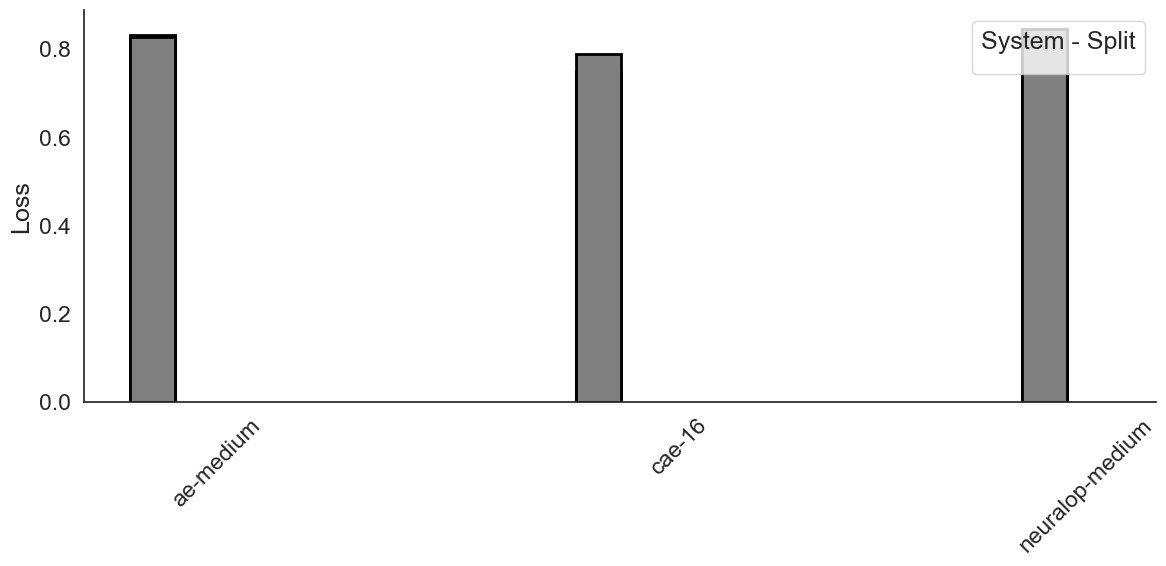

/var/folders/km/t7rply955cdgx67pfmsv62z80000gn/T/ipykernel_82408/884988800.py:191: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="System - Split")


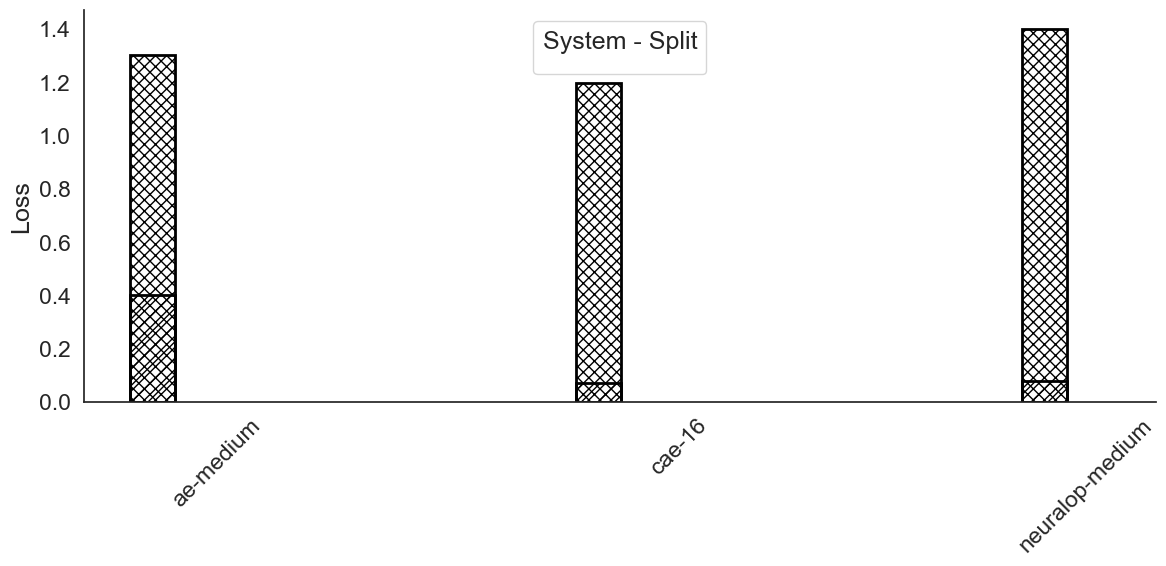

In [17]:
studies = [
    "ae-architecture-gastruloid", "cae-latentdim-gastruloid", "neuralop-architecture-gastruloid",
    # "ae-architecture-ARCADE", "cae-architecture-ARCADE", "neuralop-architecture-ARCADE"
]
loss_data = collect_all_losses(studies, only_best=True)

for study in list(loss_data.keys()):
    loss_data[study] = {
        experiment: models
        for experiment, models in loss_data[study].items()
        if "small" not in experiment and "2" not in experiment and "4" not in experiment and "large" not in experiment
    }

records = []
for study, experiments in loss_data.items():
    for experiment, models in experiments.items():
        for model_name, losses in models.items():
            for loss_type in ["image", "timepoint"]:
                for split in ["train", "val"]:
                    loss_value = losses[split].get(loss_type)
                    if loss_value is not None:
                        records.append({
                            "Study": study,
                            "Experiment": experiment,
                            "Model": model_name,
                            "Split": "Train" if split == "train" else "Validation",
                            "Loss Type": "Image" if loss_type == "image" else "Timepoint",
                            "Loss": loss_value
                        })

df = pd.DataFrame(records)
df["System"] = df["Study"].apply(lambda s: "Gastruloid" if "gastruloid" in s.lower() else "ARCADE")

plot_grouped_loss(df, loss_type="Image")
plot_grouped_loss(df, loss_type="Timepoint")

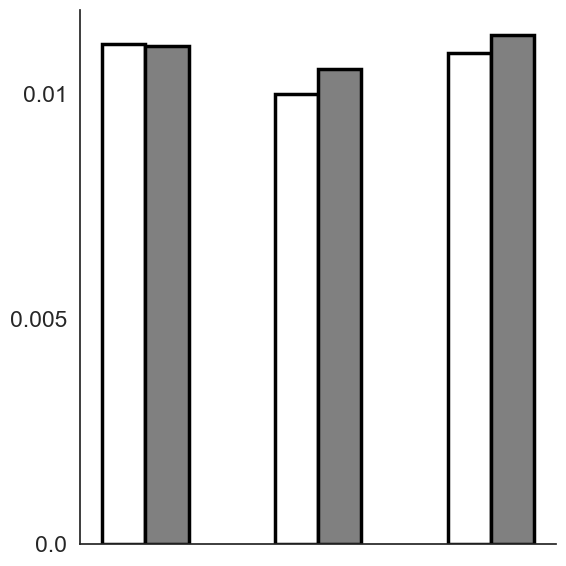

In [93]:
studies = ["ae-architecture-gastruloid", "cae-latentdim-gastruloid", "neuralop-architecture-gastruloid"]
loss_data = collect_all_losses(studies, only_best=True)

for study in list(loss_data.keys()):
    loss_data[study] = {
        experiment: models
        for experiment, models in loss_data[study].items()
        if "small" not in experiment and "2" not in experiment and "4" not in experiment and "large" not in experiment
    }
model_type = "gastruloid-all"
plot_loss_comparison(loss_data)

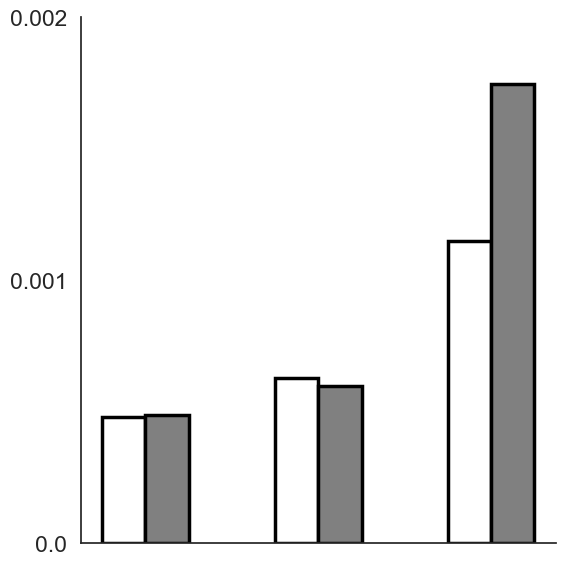

In [95]:
studies = ["ae-architecture-ARCADE", "cae-architecture-ARCADE", "neuralop-architecture-ARCADE"]
loss_data = collect_all_losses(studies, only_best=True)

for study in list(loss_data.keys()):
    loss_data[study] = {
        experiment: models
        for experiment, models in loss_data[study].items()
        if "small" not in experiment and "2" not in experiment and "4" not in experiment and "large" not in experiment
    }
model_type = "ARCITECTURE-all"
plot_loss_comparison(loss_data, y_ticks=[0.0, 0.001, 0.002])

In [5]:
studies = [
    "ae-architecture-gastruloid",
    "cae-latentdim-gastruloid",
    "neuralop-architecture-gastruloid"
]
image_dir = "data"
num_timepoints = 9
all_models = {}
all_loaders = {}

for study_name in studies:
    results_dir = f"results/{study_name}"

    models = load_models(results_dir, num_timepoints=num_timepoints, best_models_flag=True)
    filtered_models = {
        k: v for k, v in models.items()
        if all(sub not in k for sub in ["small", "2", "4", "large"])
    }
    all_models[study_name] = dict(sorted(filtered_models.items()))

    loaders = load_loaders(results_dir, image_dir)
    all_loaders[study_name] = loaders

for study, models in all_models.items():
    print(f"{study}: {list(models.keys())}")

Loading model ae_small (3.50e+07 parameters)
Loading model ae_medium (7.27e+07 parameters)
Loading model cae_medium (8.69e+06 parameters)
Loading model cae_medium (8.72e+06 parameters)
Loading model cae_medium (8.69e+06 parameters)
Loading model cae_medium (8.70e+06 parameters)
Loading model neuralop_small (3.39e+07 parameters)
Loading model neuralop_large (6.82e+07 parameters)
Loading model neuralop_medium (3.41e+07 parameters)
Loading model neuralop_large (6.82e+07 parameters)
ae-architecture-gastruloid: ['ae-medium']
cae-latentdim-gastruloid: ['cae-16']
neuralop-architecture-gastruloid: ['neuralop-medium']


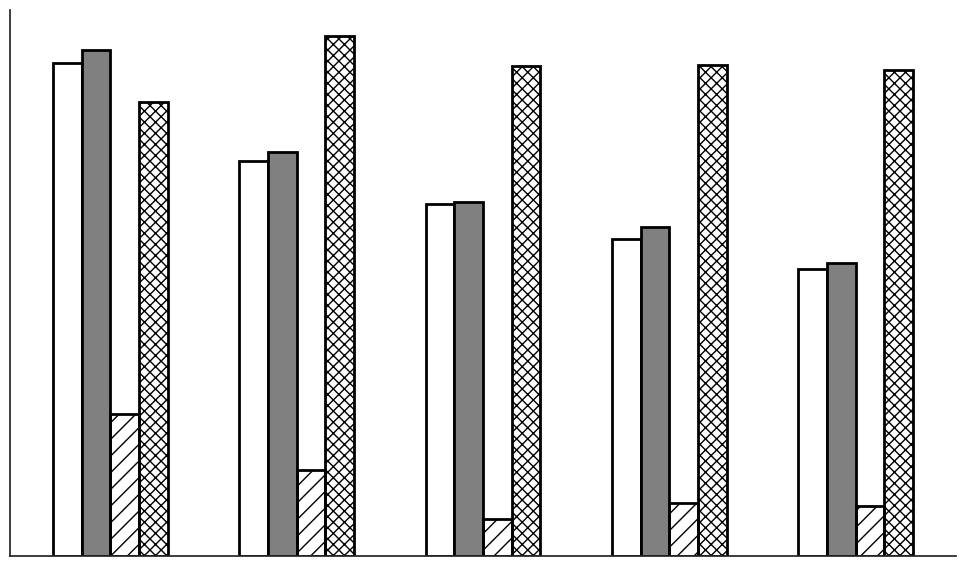

In [6]:
studies = ["neuralop-latentdim-gastruloid"]
loss_data = collect_all_losses(studies, only_best=True)
model_type = "neuralop"
plot_loss_comparison(loss_data, save_path=f"figures/plots/{model_type}_combined_loss.png")

defaultdict(<function collect_all_losses.<locals>.<lambda> at 0x330c0d260>, {'ae-architecture-ARCADE': {'ae-medium': {'_best_model': {'train': {'image': 0.0004798223865305307, 'timepoint': 2.7770215279255623, 'weighted_loss': 0.0004798223865305307}, 'val': {'image': 0.0004883469216323686, 'timepoint': 2.742184111412535, 'weighted_loss': 0.0004883469216323686}}}}, 'cae-architecture-ARCADE': {'cae-medium': {'_best_model': {'train': {'image': 0.0006289868708100289, 'timepoint': 0.6878028797055222, 'weighted_loss': 0.06934637724228375}, 'val': {'image': 0.0005971336328737844, 'timepoint': 1.1897706029579995, 'weighted_loss': 0.11954648759057547}}}}, 'neuralop-latentdim-ARCADE-16': {'neuralop-16': {'_best_model': {'train': {'image': 0.0007607217664709629, 'timepoint': 0.8457105048066981, 'weighted_loss': 0.08607112790323913}, 'val': {'image': 0.0007513467790750896, 'timepoint': 1.2701664387862732, 'weighted_loss': 0.1277193862231488}}}}})


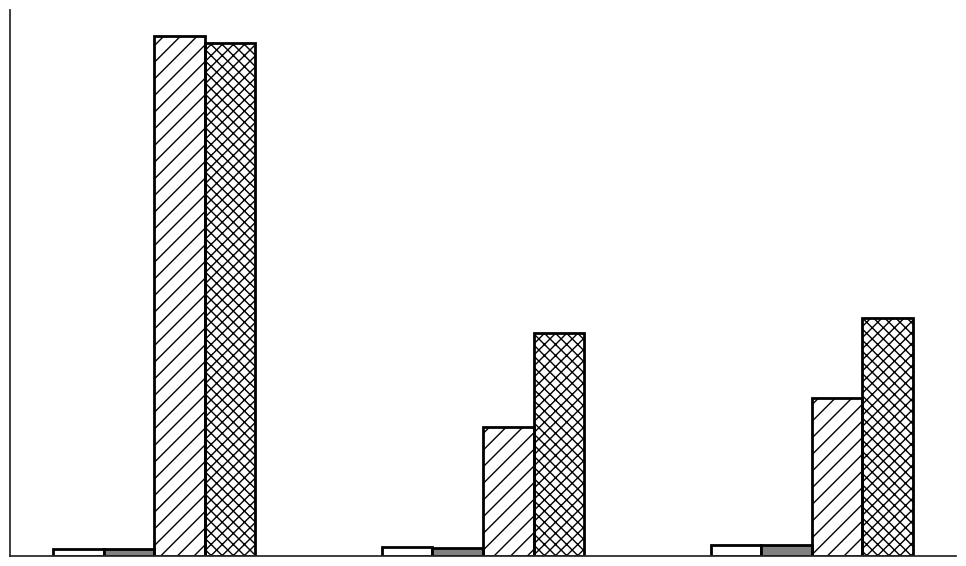

In [7]:
studies = ["ae-architecture-ARCADE", "cae-architecture-ARCADE", "neuralop-latentdim-ARCADE-16"]
loss_data = collect_all_losses(studies, only_best=True)

for study in list(loss_data.keys()):
    loss_data[study] = {
        experiment: models
        for experiment, models in loss_data[study].items()
        if "small" not in experiment
    }

print(loss_data)
model_type = "ARCADE-all"
plot_loss_comparison(loss_data, save_path=f"figures/plots/{model_type}_combined_loss.png")

In [8]:
studies = ["ae-error-ARCADE", "cae-error-ARCADE", "neuralop-error-ARCADE"]

def get_best_losses(base_dir, studies_list, split='val'):
    all_results = {}

    for study in studies_list:
        study_path = base_dir / study
        if not study_path.is_dir():
            print(f"Warning: Study folder not found at {study_path}")
            continue

        all_results[study] = {
            f"best_{split}_image_loss": [],
            f"best_{split}_timepoint_loss": [],
        }

        for experiment_path in study_path.iterdir():
            if not experiment_path.is_dir():
                continue

            results_file = experiment_path / "_best_model" / "vascular_function_128" / "results.json"
            # results_file = experiment_path / "_best_model" / "gastruloid_processed_128" / "results.json"

            if results_file.exists():
                try:
                    with open(results_file, 'r') as f:
                        data = json.load(f)

                    split_data = data.get("losses", {}).get(split, {})
                    image_losses = split_data.get("image", [])
                    timepoint_losses = split_data.get("timepoint", [])

                    if image_losses:
                        all_results[study][f"best_{split}_image_loss"].append(min(image_losses))
                    if timepoint_losses:
                        all_results[study][f"best_{split}_timepoint_loss"].append(min(timepoint_losses))

                except (json.JSONDecodeError, KeyError) as e:
                    print(f"Error processing {results_file}: {e}")
            else:
                print(f"Warning: results.json not found in {experiment_path}")

    return all_results

val_results = get_best_losses(Path("results"), studies, split="val")
train_results = get_best_losses(Path("results"), studies, split="train")
val_results

{'ae-error-ARCADE': {'best_val_image_loss': [0.0006216325859218449,
   0.0006162092731949784,
   0.0006119448954315034,
   0.0006235606327189747,
   0.0006282829957118783,
   0.0006283250584872687,
   0.0006148211440960679,
   0.0006224451385509034,
   0.0006230473897263205,
   0.0006191288053703326],
  'best_val_timepoint_loss': [1.1741399313224123,
   1.1727990939262065,
   1.1701688796598861,
   1.1771835695872916,
   1.1577260510084477,
   1.16868839856792,
   1.1829444252430124,
   1.1666268360741594,
   1.1652302791146523,
   1.1616435420322926]},
 'cae-error-ARCADE': {'best_val_image_loss': [0.0006993884034795399,
   0.0007092300862070183,
   0.0007106340110228902,
   0.0007033643680110702,
   0.0006850278486455593,
   0.0006957233067139973,
   0.0006959909876465471,
   0.0006764897802024782,
   0.0006579544106956591,
   0.0006811211605189725],
  'best_val_timepoint_loss': [1.2210751321721585,
   1.189460888029413,
   1.2072325367876824,
   1.2170165365046643,
   1.2421167069610

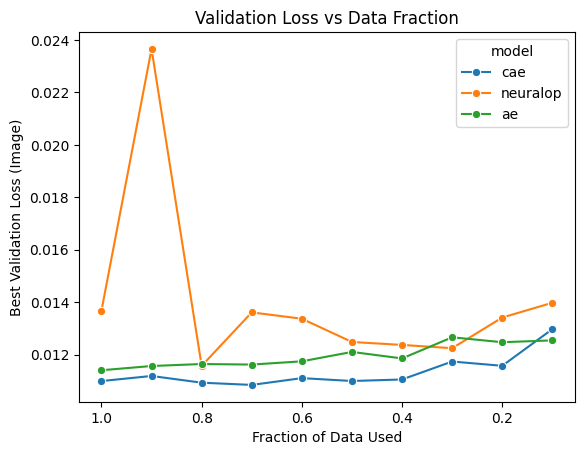

In [25]:
results_dir = Path("results/data-quantity-gastruloid")
records = []

for frac_dir in results_dir.glob("*_frac*"):
    model_type = frac_dir.name.split("-")[0]
    best_model_path = frac_dir / "_best_model" / "gastruloid_processed_128" / "results.json"
    if best_model_path.exists():
        with open(best_model_path, "r") as f:
            data = json.load(f)
        
        frac_str = frac_dir.name.split("_frac")[-1]
        frac = int(frac_str) / 100

        val_image_losses = data["losses"].get("val", {}).get("image", [])
        best_val_loss = min(val_image_losses) if val_image_losses else None

        records.append({
            "model": model_type,
            "frac": frac,
            "best_val_loss": best_val_loss
        })

df = pd.DataFrame(records).sort_values("frac")

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=df,
    x="frac",
    y="best_val_loss",
    hue="model",
    marker="o"
)

plt.gca().invert_xaxis()
plt.xlabel("Fraction of Data Used")
plt.ylabel("Best Validation Loss (Image)")
plt.title("Validation Loss vs Data Fraction")
plt.show()

In [9]:
studies = list(val_results.keys())
image_loss_groups = {study: val_results[study]["best_val_image_loss"] for study in studies}
timepoint_loss_groups = {study: val_results[study]["best_val_timepoint_loss"] for study in studies}

num_comparisons = len(list(combinations(studies, 2)))
alpha = 0.05
bonferroni_alpha = alpha / num_comparisons

print(f"--- T-test Analysis with Bonferroni Correction ---")
print(f"Original Significance Level (Alpha): {alpha}")
print(f"Number of Pairwise Comparisons: {num_comparisons}")
print(f"Bonferroni Corrected Alpha: {bonferroni_alpha:.4f}")
print("-" * 50)

print("\nAnalyzing 'Image Loss' Groups:")
for (study1, study2) in combinations(studies, 2):
    group1 = image_loss_groups[study1]
    group2 = image_loss_groups[study2]

    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)

    print(f"\nComparison: {study1} vs. {study2}")
    print(f"t-statistic: {t_stat}, P-value: {p_val}")

    if p_val < bonferroni_alpha:
        print(f"Result: Statistically significant (p < {bonferroni_alpha:.4f})")
    else:
        print(f"Result: Not statistically significant (p >= {bonferroni_alpha:.4f})")

print("-" * 50)

print("\nAnalyzing 'Timepoint Loss' Groups:")
for (study1, study2) in combinations(studies, 2):
    group1 = timepoint_loss_groups[study1]
    group2 = timepoint_loss_groups[study2]

    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)

    print(f"\nComparison: {study1} vs. {study2}")
    print(f"t-statistic: {t_stat}, P-value: {p_val}")

    if p_val < bonferroni_alpha:
        print(f"Result: Statistically significant (p < {bonferroni_alpha:.4f})")
    else:
        print(f"Result: Not statistically significant (p >= {bonferroni_alpha:.4f})")

--- T-test Analysis with Bonferroni Correction ---
Original Significance Level (Alpha): 0.05
Number of Pairwise Comparisons: 3
Bonferroni Corrected Alpha: 0.0167
--------------------------------------------------

Analyzing 'Image Loss' Groups:

Comparison: ae-error-ARCADE vs. cae-error-ARCADE
t-statistic: -12.90931111105869, P-value: 5.701460804985507e-08
Result: Statistically significant (p < 0.0167)

Comparison: ae-error-ARCADE vs. neuralop-error-ARCADE
t-statistic: -8.802238928919639, P-value: 1.0231141377910199e-05
Result: Statistically significant (p < 0.0167)

Comparison: cae-error-ARCADE vs. neuralop-error-ARCADE
t-statistic: -8.551222898865246, P-value: 1.2893158233333352e-05
Result: Statistically significant (p < 0.0167)
--------------------------------------------------

Analyzing 'Timepoint Loss' Groups:

Comparison: ae-error-ARCADE vs. cae-error-ARCADE
t-statistic: -8.472076082273304, P-value: 8.073352004240136e-07
Result: Statistically significant (p < 0.0167)

Comparison

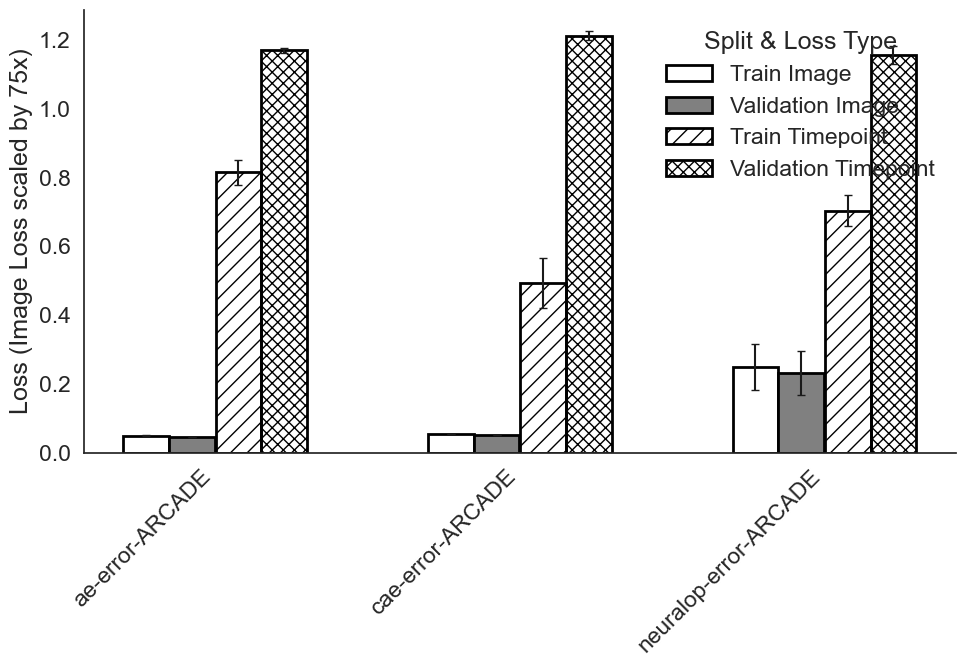

In [10]:
def plot_loss_comparison_with_errors(train_results, val_results, figsize=(10, 7), save_path=None):
    records = []
    all_models = list(train_results.keys())

    for model in all_models:
        train_img_mean = np.mean(train_results[model]["best_train_image_loss"])
        train_img_std = np.std(train_results[model]["best_train_image_loss"])
        train_tp_mean = np.mean(train_results[model]["best_train_timepoint_loss"])
        train_tp_std = np.std(train_results[model]["best_train_timepoint_loss"])
        
        val_img_mean = np.mean(val_results[model]["best_val_image_loss"])
        val_img_std = np.std(val_results[model]["best_val_image_loss"])
        val_tp_mean = np.mean(val_results[model]["best_val_timepoint_loss"])
        val_tp_std = np.std(val_results[model]["best_val_timepoint_loss"])

        records.extend([
            {"Model": model, "Split": "Train", "Loss Type": "Image", "Loss": train_img_mean, "StdDev": train_img_std},
            {"Model": model, "Split": "Validation", "Loss Type": "Image", "Loss": val_img_mean, "StdDev": val_img_std},
            {"Model": model, "Split": "Train", "Loss Type": "Timepoint", "Loss": train_tp_mean, "StdDev": train_tp_std},
            {"Model": model, "Split": "Validation", "Loss Type": "Timepoint", "Loss": val_tp_mean, "StdDev": val_tp_std}
        ])

    df = pd.DataFrame(records)

    sns.set_theme(style="white", font_scale=1.5)
    plt.figure(figsize=figsize)
    ax = plt.gca()

    models = df["Model"].unique()
    width = 0.12
    x = np.arange(len(models)) * 0.8
    bar_order = [("Train", "Image"), ("Validation", "Image"), ("Train", "Timepoint"), ("Validation", "Timepoint")]
    gap = 0.02

    for i, model in enumerate(models):
        model_df = df[df["Model"] == model]
        for j, (split, loss_type) in enumerate(bar_order):
            bar_df = model_df[(model_df["Split"] == split) & (model_df["Loss Type"] == loss_type)]
            if bar_df.empty:
                continue

            loss = bar_df["Loss"].values[0]
            std_dev = bar_df["StdDev"].values[0]

            if loss_type == "Image":
                loss *= 75
                std_dev *= 75

            offset_base = j + (gap if j >= 2 else 0)
            offset = (offset_base - 1.5) * width
            
            label = f"{split} {loss_type}" if i == 0 else ""

            bar_kwargs = {
                "x": x[i] + offset,
                "height": loss,
                "width": width,
                "edgecolor": "black",
                "label": label,
                "linewidth": 2.0,
                "color": "none",
                "yerr": std_dev,
                "capsize": 3
            }

            if loss_type == "Timepoint":
                bar_kwargs["hatch"] = "//" if split == "Train" else "xxx"
            elif split == "Validation":
                bar_kwargs["color"] = "gray"

            ax.bar(**bar_kwargs)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel("Loss (Image Loss scaled by 75x)")
    sns.despine()
    ax.grid(False)
    plt.legend(frameon=False, title="Split & Loss Type")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()
    else:
        plt.show()


plot_loss_comparison_with_errors(train_results, val_results)


Processing cae...


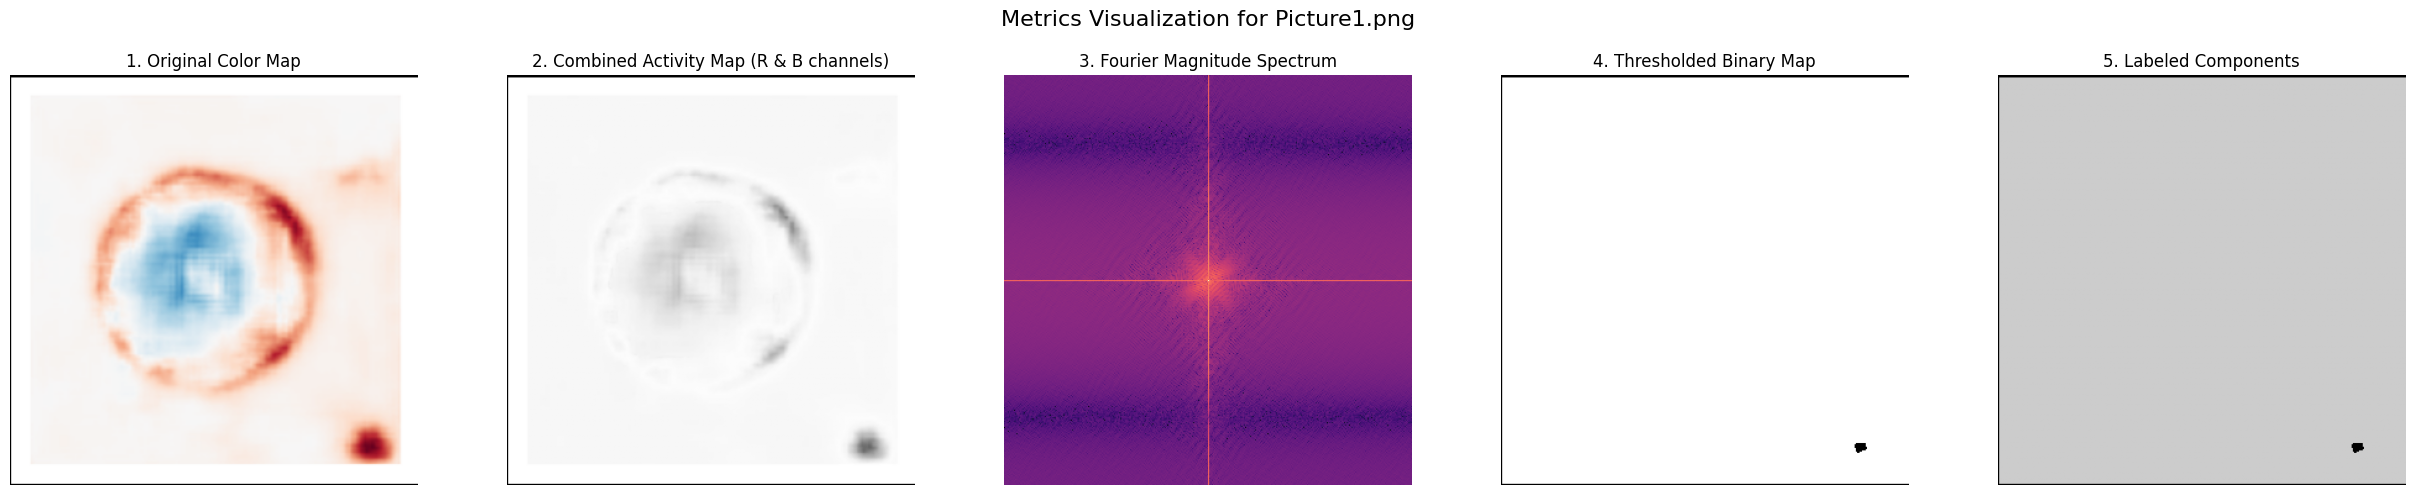

Processing neuralop...


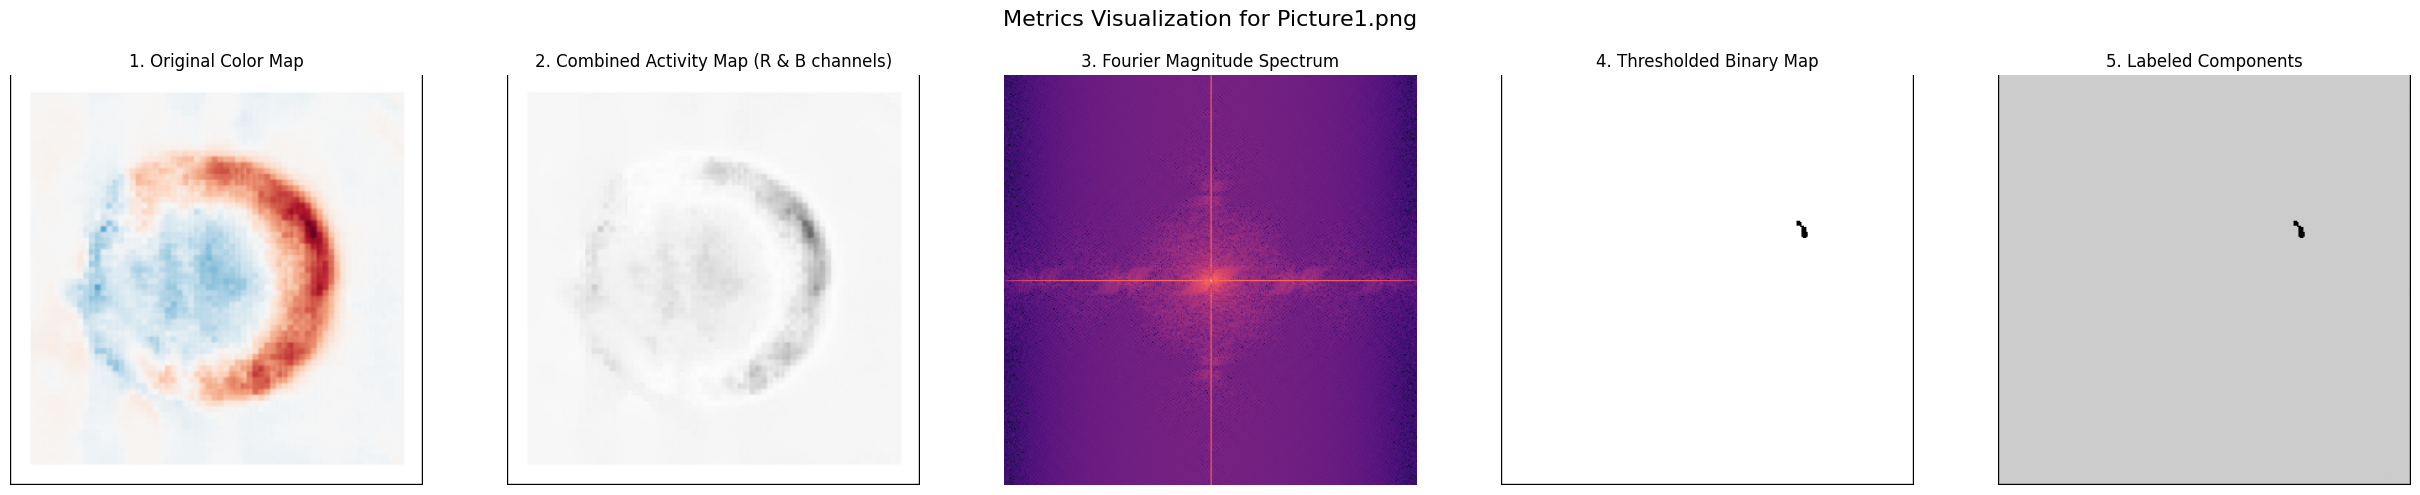


--- Quantitative Metrics ---
Average High-Frequency Energy Ratio:
  cae: 0.9544
  neuralop: 0.9558

Average Image Entropy:
  cae: 3.6421
  neuralop: 4.0351
A higher value indicates a more random/chaotic pattern (more fine-grained learning).

Average Connected Component Size (in pixels):
  cae: 108181.00
  neuralop: 109835.00
A larger average size indicates larger, more contiguous regions of error (more global learning).


In [3]:
import cv2
from skimage import measure, filters

def visualize_metrics(original_color_img, activity_map, magnitude_spectrum, binary_img, labeled_img, filename):
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(f"Metrics Visualization for {filename}", fontsize=16)

    # Plot 1: Original Color Image
    # OpenCV reads as BGR, so we convert to RGB for correct display
    axes[0].imshow(cv2.cvtColor(original_color_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Original Color Map")
    axes[0].axis('off')

    # Plot 2: Combined Activity Map
    axes[1].imshow(activity_map, cmap='gray')
    axes[1].set_title("2. Combined Activity Map (R & B channels)")
    axes[1].axis('off')

    # Plot 3: Fourier Magnitude Spectrum
    axes[2].imshow(magnitude_spectrum, cmap='magma')
    axes[2].set_title("3. Fourier Magnitude Spectrum")
    axes[2].axis('off')

    # Plot 4: Binary Thresholded Image (for Connected Components)
    axes[3].imshow(binary_img, cmap='gray')
    axes[3].set_title("4. Thresholded Binary Map")
    axes[3].axis('off')

    # Plot 5: Labeled Connected Components
    # We use a colormap to distinguish different components
    axes[4].imshow(labeled_img, cmap='nipy_spectral')
    axes[4].set_title("5. Labeled Components")
    axes[4].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout
    plt.show()

def process_images_in_folder(folder_path, visualize=True):

    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    entropies = []
    high_freq_energies = []
    avg_component_sizes = []
    
    for filename in image_files:
        if "1" not in filename:
            continue
        img_path = os.path.join(folder_path, filename)
        
        # Read the image in color
        original_color_img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        
        if original_color_img is None:
            print(f"Warning: Could not read image {img_path}")
            continue

        # Split the BGR channels
        b, g, r = cv2.split(original_color_img)
        
        # Create a single "activity" map by taking the maximum of the R and B channels
        # This preserves the magnitude of the difference while ignoring color.
        activity_map = np.maximum(r, b).astype(np.float32)

        # 1. Spatial Frequency Analysis (Fourier Transform)
        f_transform = np.fft.fft2(activity_map)
        f_shift = np.fft.fftshift(f_transform)
        magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1e-8)

        rows, cols = activity_map.shape
        center_row, center_col = rows // 2, cols // 2
        
        radius = min(rows, cols) // 10 
        y, x = np.ogrid[:rows, :cols]
        center_mask = ((y - center_row)**2 + (x - center_col)**2) <= radius**2
        
        low_freq_energy = np.sum(magnitude_spectrum[center_mask])
        high_freq_energy = np.sum(magnitude_spectrum[~center_mask])
        
        high_freq_energies.append(high_freq_energy / (low_freq_energy + high_freq_energy))

        # 2. Image Entropy
        activity_map_norm = cv2.normalize(activity_map, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        entropies.append(measure.shannon_entropy(activity_map_norm))

        # 3. Spatial Clustering Metrics (Connected Components)
        thresh = filters.threshold_otsu(activity_map_norm)
        binary_img = activity_map_norm > thresh
        
        labeled_img = measure.label(binary_img, connectivity=2)
        
        regions = measure.regionprops(labeled_img)
        
        if regions:
            avg_area = np.mean([region.area for region in regions])
            avg_component_sizes.append(avg_area)
        else:
            avg_component_sizes.append(0)

        # --- Visualization Section ---
        if visualize:
            visualize_metrics(original_color_img, activity_map, magnitude_spectrum, binary_img, labeled_img, filename)

    return entropies, high_freq_energies, avg_component_sizes

def main():
    model_1_path = 'results_downstream/diff_maps/cae'
    model_2_path = 'results_downstream/diff_maps/neuralop'

    print("Processing cae...")
    entropies_1, high_freqs_1, components_1 = process_images_in_folder(model_1_path)
    
    print("Processing neuralop...")
    entropies_2, high_freqs_2, components_2 = process_images_in_folder(model_2_path)
    
    print("\n--- Quantitative Metrics ---")
    
    # Metric 1: Average High-Frequency Energy Ratio
    avg_high_freq_1 = np.mean(high_freqs_1)
    avg_high_freq_2 = np.mean(high_freqs_2)
    print(f"Average High-Frequency Energy Ratio:")
    print(f"  cae: {avg_high_freq_1:.4f}")
    print(f"  neuralop: {avg_high_freq_2:.4f}")
    
    # Metric 2: Average Image Entropy
    avg_entropy_1 = np.mean(entropies_1)
    avg_entropy_2 = np.mean(entropies_2)
    print(f"\nAverage Image Entropy:")
    print(f"  cae: {avg_entropy_1:.4f}")
    print(f"  neuralop: {avg_entropy_2:.4f}")
    print("A higher value indicates a more random/chaotic pattern (more fine-grained learning).")
    
    # Metric 3: Average Connected Component Size
    avg_comp_size_1 = np.mean(components_1)
    avg_comp_size_2 = np.mean(components_2)
    print(f"\nAverage Connected Component Size (in pixels):")
    print(f"  cae: {avg_comp_size_1:.2f}")
    print(f"  neuralop: {avg_comp_size_2:.2f}")
    print("A larger average size indicates larger, more contiguous regions of error (more global learning).")
    
if __name__ == "__main__":
    main()

In [6]:
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import sobel
from skimage.measure import shannon_entropy
import matplotlib.pyplot as plt

from skimage import data
from skimage.util import img_as_ubyte
from skimage.filters.rank import entropy
from skimage.morphology import disk

def analyze_image(image_path):
    img = imread(image_path)
    red = img[..., 0].astype(float)
    blue = img[..., 2].astype(float)

    red /= red.max() if red.max() > 0 else 1
    blue /= blue.max() if blue.max() > 0 else 1

    red_edges = sobel(red)
    blue_edges = sobel(blue)

    red_thresh = red > 0.8
    blue_thresh = blue > 0.8

    red_entropy = shannon_entropy(red)
    blue_entropy = shannon_entropy(blue)

    disk_size = 10
    red_ent_image = entropy(red, disk(disk_size))
    blue_ent_image = entropy(blue, disk(disk_size))

    red_entropy = red_ent_image.mean()
    blue_entropy = blue_ent_image.mean()

    # print(image_path)
    # plt.figure(figsize=(16, 4))
    # plt.subplot(1, 5, 1)
    # plt.imshow(img, cmap='RdBu')
    # plt.title("Red Channel")
    # plt.axis("off")

    # plt.subplot(1, 5, 2)
    # plt.imshow(red_thresh, cmap='Reds')
    # plt.title("Red Channel")
    # plt.axis("off")

    # plt.subplot(1, 5, 3)
    # plt.imshow(red_ent_image, cmap='gray')
    # plt.title("Red Entropy")
    # plt.axis("off")

    # plt.subplot(1, 5, 4)
    # plt.imshow(blue_thresh, cmap='Blues')
    # plt.title("Blue Channel")
    # plt.axis("off")

    # plt.subplot(1, 5, 5)
    # plt.imshow(blue_ent_image, cmap='gray')
    # plt.title("Blue Entropy")
    # plt.axis("off")
    # plt.show()
    overlap = np.logical_and(red_thresh, blue_thresh).sum() / red.size

    return {
        'red_entropy': red_entropy,
        'blue_entropy': blue_entropy,
        'red_edge_mean': red_edges.mean(),
        'blue_edge_mean': blue_edges.mean(),
        'overlap': overlap,
    }

def analyze_folder(folder_path, filenames):
    stats = {
        'red_entropy': [],
        'blue_entropy': [],
        'red_edge_mean': [],
        'blue_edge_mean': [],
        'overlap': [],
    }

    for fname in filenames:
        image_path = os.path.join(folder_path, fname)
        result = analyze_image(image_path)
        for key in stats:
            stats[key].append(result[key])

    # Average stats
    avg_stats = {key: np.mean(values) for key, values in stats.items()}
    return avg_stats

image_filenames = [f"Picture{i}.png" for i in range(1, 7)]

folder1 = "results_downstream/diff_maps/cae/gray"
folder2 = "results_downstream/diff_maps/neuralop"

stats1 = analyze_folder(folder1, image_filenames)
stats2 = analyze_folder(folder2, image_filenames)

print("Folder 1 Average Stats:", stats1)
print("Folder 2 Average Stats:", stats2)

/var/folders/km/t7rply955cdgx67pfmsv62z80000gn/T/ipykernel_19670/2429567455.py:85: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  result = analyze_image(image_path)
/var/folders/km/t7rply955cdgx67pfmsv62z80000gn/T/ipykernel_19670/2429567455.py:85: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  result = analyze_image(image_path)
/var/folders/km/t7rply955cdgx67pfmsv62z80000gn/T/ipykernel_19670/2429567455.py:85: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  result = analyze_image(image_path)
/var/folders/km/t7rply955cdgx67pfmsv62z80000gn/T/ipykernel_19670/2429567455.py:85: UserWarning

Folder 1 Average Stats: {'red_entropy': np.float64(3.019471928627654), 'blue_entropy': np.float64(3.019471928627654), 'red_edge_mean': np.float64(0.01941590723551372), 'blue_edge_mean': np.float64(0.01941590723551372), 'overlap': np.float64(0.17883695334785832)}
Folder 2 Average Stats: {'red_entropy': np.float64(3.36601401251782), 'blue_entropy': np.float64(3.36601401251782), 'red_edge_mean': np.float64(0.02289483972213757), 'blue_edge_mean': np.float64(0.02289483972213757), 'overlap': np.float64(0.18310834587423164)}


In [16]:
import os
import cv2
import numpy as np
from skimage import morphology
from skimage.feature import blob_log
from scipy.ndimage import sum as ndi_sum

FOLDER_1 = "results_downstream/diff_maps/cae/gray"
FOLDER_2 = "results_downstream/diff_maps/neuralop"

def calculate_laplacian_variance(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return cv2.Laplacian(image, cv2.CV_64F).var()

def calculate_freq_ratio(image_path, radius_ratio=0.001):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
    f_transform = np.fft.fft2(image)
    f_transform_shifted = np.fft.fftshift(f_transform)
    power_spectrum = np.abs(f_transform_shifted)**2

    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2
    
    radius = int(radius_ratio * min(rows, cols))
    
    mask = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask, (ccol, crow), radius, 1, thickness=-1)

    low_freq_energy = np.sum(power_spectrum[mask == 1])
    high_freq_energy = np.sum(power_spectrum[mask == 0])

    if low_freq_energy == 0:
        return np.inf
        
    return high_freq_energy / low_freq_energy

def calculate_granulometry_metric(image_path, max_size=20):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None

    original_sum = np.sum(image.astype(np.float64))
    if original_sum == 0:
        return 0

    sizes = range(1, max_size, 2)
    spectrum = []
    prev_sum = original_sum
    
    for k in sizes:
        selem = morphology.disk(k)
        opened = morphology.opening(image, selem)
        current_sum = np.sum(opened.astype(np.float64))
        spectrum.append(prev_sum - current_sum)
        prev_sum = current_sum
    
    if sum(spectrum) == 0:
        return 0
    mean_size = sum(s * v for s, v in zip(sizes, spectrum)) / sum(spectrum)
    return mean_size

def calculate_blob_metric(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    
    image_inverted = np.max(image) - image
    
    blobs_bright = blob_log(image, min_sigma=1, max_sigma=30, num_sigma=10, threshold=.3)
    blobs_dark = blob_log(image_inverted, min_sigma=1, max_sigma=30, num_sigma=10, threshold=.3)
    
    all_blobs = []
    if blobs_bright.shape[0] > 0:
        all_blobs.extend(blobs_bright[:, 2]) 
    if blobs_dark.shape[0] > 0:
        all_blobs.extend(blobs_dark[:, 2])

    if not all_blobs:
        return 0
    
    return np.mean(np.square(all_blobs))

def analyze_image_folder(folder_path):
    laplacian_scores = []
    freq_ratios = []
    granulometry_scores = []
    blob_scores = []
    
    if not os.path.isdir(folder_path):
        print(f"Error: Folder not found at {folder_path}")
        return None, None

    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif'))]

    if not image_files:
        print(f"Warning: No images found in {folder_path}")
        return None, None

    for filename in image_files:
        image_path = os.path.join(folder_path, filename)
        
        lap_var = calculate_laplacian_variance(image_path)
        if lap_var is not None:
            laplacian_scores.append(lap_var)
        
        freq_ratio = calculate_freq_ratio(image_path)
        if freq_ratio is not None:
            freq_ratios.append(freq_ratio)

        granulometry = calculate_granulometry_metric(image_path)
        if granulometry is not None:
            granulometry_scores.append(granulometry)

        blob = calculate_granulometry_metric(image_path)
        if blob is not None:
            blob_scores.append(blob)

    avg_laplacian = np.mean(laplacian_scores) if laplacian_scores else 0
    avg_freq_ratio = np.mean(freq_ratios) if freq_ratios else 0
    avg_granulometry = np.mean(granulometry_scores) if granulometry_scores else 0
    avg_blob = np.mean(blob_scores) if blob_scores else 0
    
    return avg_laplacian, avg_freq_ratio, avg_granulometry, avg_blob

if __name__ == "__main__":
    folders_to_analyze = {
        "cae": FOLDER_1,
        "neuralop": FOLDER_2
    }

    for model_name, folder_path in folders_to_analyze.items():
        print(f"Processing folder for {model_name}: {folder_path}")
        
        avg_lap, avg_freq, avg_granulometry, avg_blob = analyze_image_folder(folder_path)
        
        if avg_lap is not None:
            print(f"Average Laplacian Variance: {avg_lap:.2f}")
            print(f"Average High/Low Freq Ratio: {avg_freq:.4f}")
            print(f"Average Granulometry: {avg_granulometry:.4f}")
            print(f"Average blob: {avg_blob:.4f}")
            
            
            print("-" * 40)

Processing folder for cae: results_downstream/diff_maps/cae/gray
Average Laplacian Variance: 561.23
Average High/Low Freq Ratio: 0.1151
Average Granulometry: 10.7694
Average blob: 10.7694
----------------------------------------
Processing folder for neuralop: results_downstream/diff_maps/neuralop
Average Laplacian Variance: 616.90
Average High/Low Freq Ratio: 0.1390
Average Granulometry: 10.3598
Average blob: 10.3598
----------------------------------------


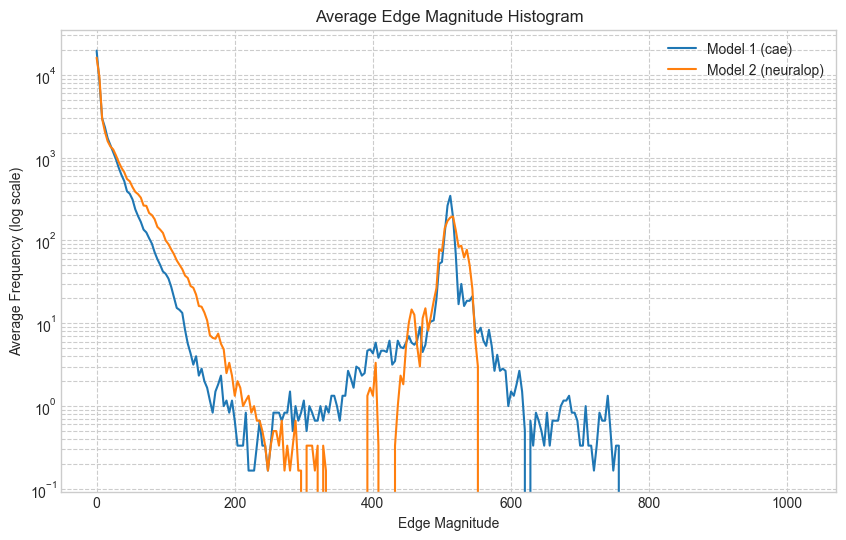

In [31]:
import matplotlib.pyplot as plt
KSIZE = 3

def calculate_average_edge_histogram(folder_path, bins=256, max_magnitude=1024):
    """
    Calculates the average histogram of edge magnitudes for all images in a folder.
    """
    if not os.path.isdir(folder_path):
        print(f"Error: Folder not found at {folder_path}")
        return None, None

    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif'))]
    if not image_files:
        print(f"Warning: No images found in {folder_path}")
        return None, None

    # Initialize accumulator for the histogram
    total_hist = np.zeros(bins)
    bin_edges = np.linspace(0, max_magnitude, bins + 1)
    num_images = 0

    for filename in image_files:
        image_path = os.path.join(folder_path, filename)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            continue

        # 1. Use Sobel filter to find gradients in x and y directions
        sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=KSIZE)
        sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=KSIZE)

        # 2. Calculate the magnitude of the gradients
        magnitude = np.sqrt(sobelx**2 + sobely**2)

        # 3. Compute histogram for the current image and add to total
        hist, _ = np.histogram(magnitude, bins=bin_edges)
        total_hist += hist
        num_images += 1

    # Return the average histogram
    return total_hist / num_images, bin_edges

### --- Main Plotting Execution --- ###

# Calculate the average histograms for both folders
hist1, bins1 = calculate_average_edge_histogram(FOLDER_1)
hist2, bins2 = calculate_average_edge_histogram(FOLDER_2)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

if hist1 is not None:
    plt.plot(bins1[:-1], hist1, label="Model 1 (cae)")
if hist2 is not None:
    plt.plot(bins2[:-1], hist2, label="Model 2 (neuralop)")

# Use a log scale on the y-axis to better see the tails of the distribution
plt.yscale('log')
plt.title("Average Edge Magnitude Histogram")
plt.xlabel("Edge Magnitude")
plt.ylabel("Average Frequency (log scale)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


--- Samples for Model 1 (cae) ---


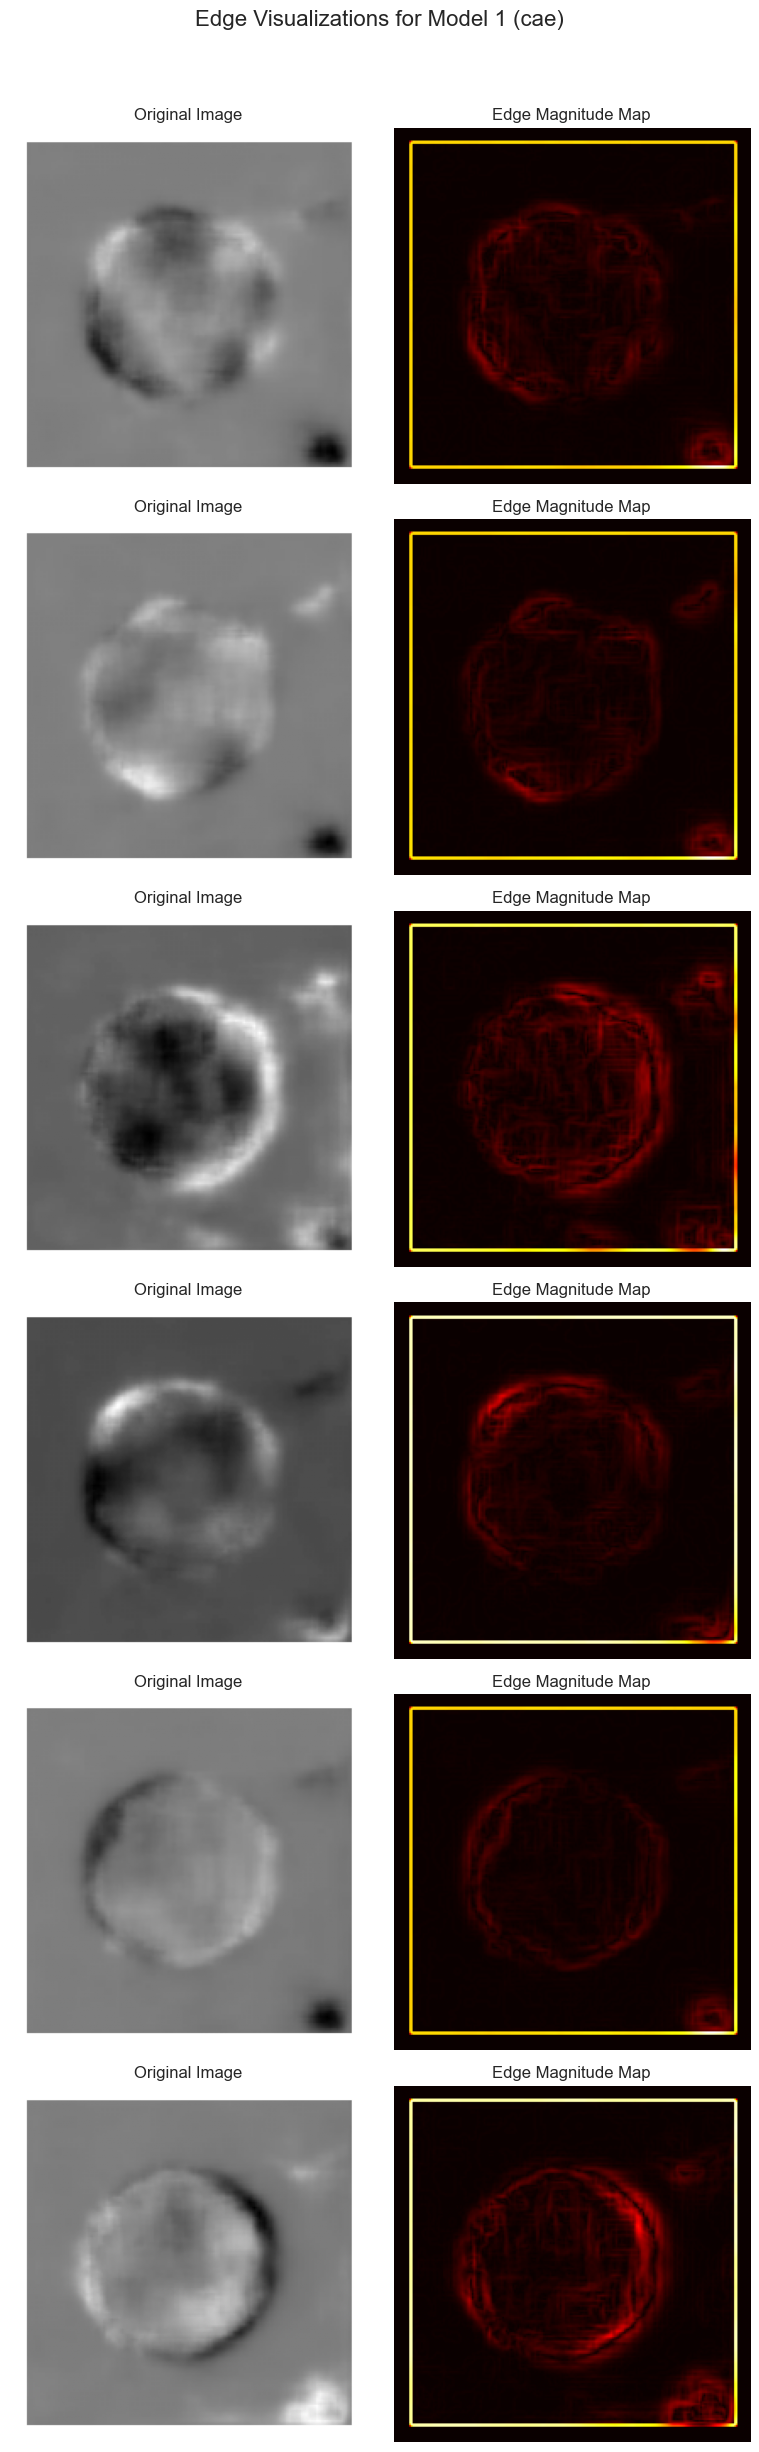


--- Samples for Model 2 (neuralop) ---


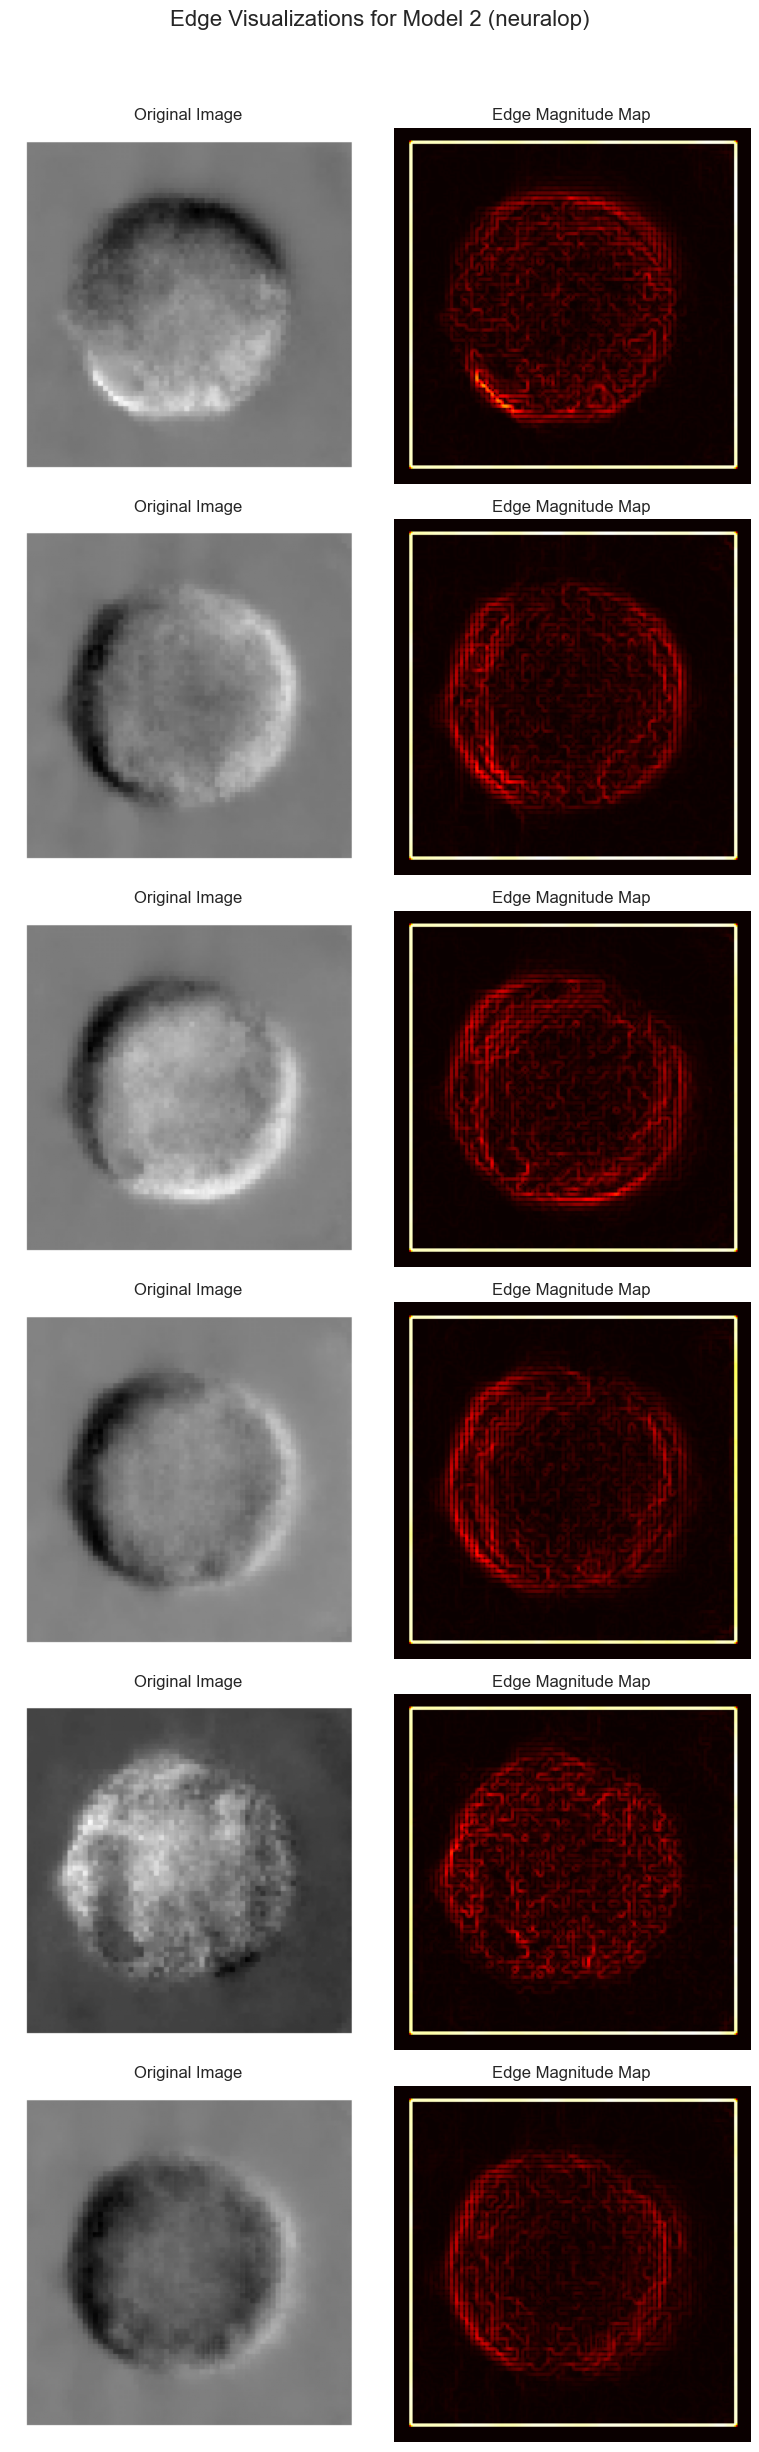

In [32]:
import random
import matplotlib.pyplot as plt

def plot_image_and_edges(image_path, ax_orig, ax_edge):
    """Helper function to plot an image and its edge map."""
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return

    # Calculate Sobel edge magnitude
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=KSIZE)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=KSIZE)
    magnitude = np.sqrt(sobelx**2 + sobely**2)

    # Plot original image
    ax_orig.imshow(image, cmap='gray')
    ax_orig.set_title("Original Image")
    ax_orig.axis('off')

    # Plot edge map
    im = ax_edge.imshow(magnitude, cmap='hot')
    ax_edge.set_title("Edge Magnitude Map")
    ax_edge.axis('off')
    return im


folders = {
    "Model 1 (cae)": FOLDER_1,
    "Model 2 (neuralop)": FOLDER_2
}
num_samples = 6

for model_name, folder_path in folders.items():
    print(f"\n--- Samples for {model_name} ---")
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif'))]
    sample_files = random.sample(image_files, min(num_samples, len(image_files)))

    fig, axes = plt.subplots(len(sample_files), 2, figsize=(8, 4 * len(sample_files)))
    if len(sample_files) == 1: # Handle case of a single sample
        axes = np.array([axes])
        
    fig.suptitle(f'Edge Visualizations for {model_name}', fontsize=16, y=1.02)

    for i, filename in enumerate(sample_files):
        image_path = os.path.join(folder_path, filename)
        plot_image_and_edges(image_path, axes[i, 0], axes[i, 1])

    plt.tight_layout()
    plt.show()

In [ ]:
from scipy.stats import skew

def calculate_edge_metrics(folder_path):
    """
    Calculates single-number metrics for the edge magnitude distribution.
    """
    if not os.path.isdir(folder_path):
        return None, None, None

    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif'))]
    if not image_files:
        return None, None, None

    all_means = []
    all_percentiles = []
    all_skews = []

    for filename in image_files:
        image_path = os.path.join(folder_path, filename)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            continue

        # Calculate edge magnitude
        sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=KSIZE)
        sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=KSIZE)
        magnitude = np.sqrt(sobelx**2 + sobely**2)

        all_means.append(np.mean(magnitude))
        all_percentiles.append(np.percentile(magnitude, 75))
        all_skews.append(skew(magnitude.flatten()))

    return np.mean(all_means), np.mean(all_percentiles), np.mean(all_skews)

for model_name, folder_path in folders.items():
    mean_mag, p90_mag, skew_mag = calculate_edge_metrics(folder_path)
    
    if mean_mag is not None:
        print(f"Metrics for {model_name}:")
        print(f"\tAverage Edge Magnitude:           {mean_mag:.2f}")
        print(f"\t90th Percentile of Edge Magnitude:  {p90_mag:.2f}")
        print(f"\tSkewness of Edge Distribution:      {skew_mag:.2f}")
        print("-" * 60)

Metrics for Model 1 (cae):
	Average Edge Magnitude:           28.01
	90th Percentile of Edge Magnitude:  16.61
	Skewness of Edge Distribution:      4.90
------------------------------------------------------------
Metrics for Model 2 (neuralop):
	Average Edge Magnitude:           33.03
	90th Percentile of Edge Magnitude:  23.57
	Skewness of Edge Distribution:      4.61
------------------------------------------------------------


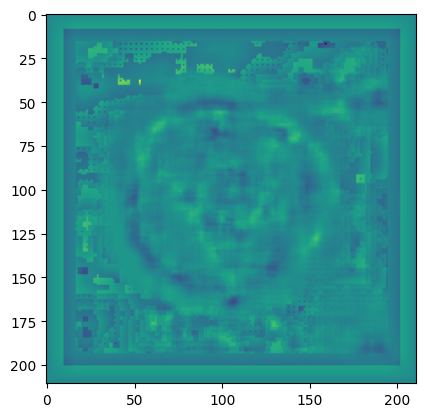

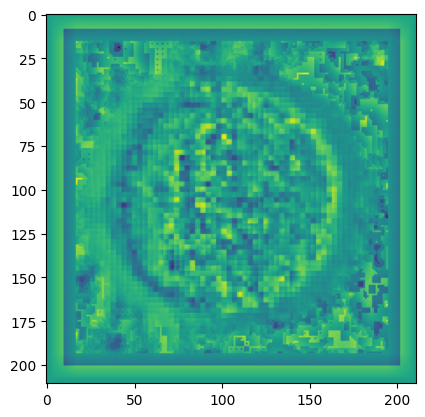

Metric                        Image 1		Image 2
------------------------------------------------------------
Local Entropy                 4.2070		4.7417
FFT High-Frequency Energy     1596306.6250		1731462.6250
GLCM Contrast                 85.7299		301.5440
Shannon Entropy               14.5717		14.8120


In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import io, filters, morphology, measure, feature
from numpy.fft import fft2, fftshift
from scipy.ndimage import uniform_filter

def load_grayscale_image(path):
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32)

def local_zscore(image, size=15):
    mean = uniform_filter(image, size=size)
    sq_mean = uniform_filter(image**2, size=size)
    std = np.sqrt(sq_mean - mean**2 + 1e-8)
    return (image - mean) / (std + 1e-5)

def compute_local_entropy(image, radius=5):
    normed = ((image - image.min()) / (image.max() - image.min()) * 255).astype(np.uint8)
    selem = morphology.disk(radius)
    ent = filters.rank.entropy(normed, selem)
    return ent.mean()

def compute_fft_highfreq_energy(image, high_ratio=0.3):
    f_transform = fftshift(np.abs(fft2(image)))
    h, w = image.shape
    cy, cx = h // 2, w // 2
    mask = np.ones_like(f_transform, dtype=bool)
    r = int(min(h, w) * high_ratio // 2)
    mask[cy - r:cy + r, cx - r:cx + r] = False
    return f_transform[mask].sum()

def compute_laplacian_variance(image):
    lap = cv2.Laplacian(image, cv2.CV_64F)
    return lap.var()

def compute_glcm_contrast(image):
    normed = ((image - image.min()) / (image.max() - image.min()) * 255).astype(np.uint8)
    glcm = feature.graycomatrix(normed, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = feature.graycoprops(glcm, 'contrast')[0, 0]
    return contrast

def compute_shannon_entropy(image):
    return measure.shannon_entropy(image)

def compare_images(img1, img2):
    # Apply local z-score normalization
    img1_z = local_zscore(img1)
    img2_z = local_zscore(img2)

    plt.imshow(img1_z)
    plt.show()
    plt.imshow(img2_z)
    plt.show()
    metrics = {
        "Local Entropy": compute_local_entropy,
        "FFT High-Frequency Energy": compute_fft_highfreq_energy,
        # "Laplacian Variance": compute_laplacian_variance,
        "GLCM Contrast": compute_glcm_contrast,
        "Shannon Entropy": compute_shannon_entropy
    }

    print(f"{'Metric':<30}Image 1\t\tImage 2")
    print("-" * 60)
    for name, func in metrics.items():
        v1 = func(img1_z)
        v2 = func(img2_z)
        print(f"{name:<30}{v1:.4f}\t\t{v2:.4f}")

# --- Replace with your paths ---
path1 = "results_downstream/diff_maps/cae/gray/Picture6.png"
path2 = "results_downstream/diff_maps/neuralop/Picture1.png"

img1 = load_grayscale_image(path1)
img2 = load_grayscale_image(path2)

compare_images(img1, img2)

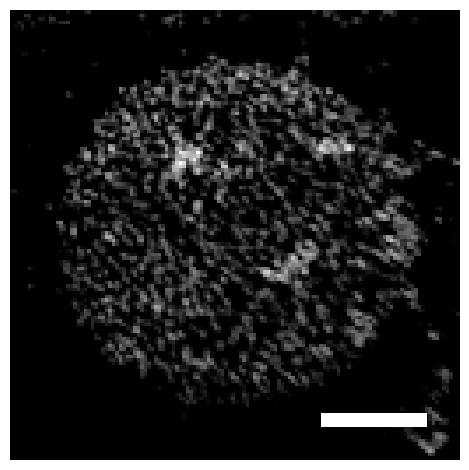

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import imageio.v3 as iio

def add_scale_bar(image_path, pixel_size_um, scale_bar_um=50, bar_height_px=4, color='white'):
    image = iio.imread(image_path)
    if image.ndim == 3:
        image = image[..., 0]

    height, width = image.shape
    scale_bar_px = int(scale_bar_um / pixel_size_um)

    fig, ax = plt.subplots()
    ax.imshow(image, cmap='gray')
    ax.axis('off')

    x_start = width - scale_bar_px - 10
    y_start = height - bar_height_px - 10

    scale_bar = patches.Rectangle(
        (x_start, y_start), scale_bar_px, bar_height_px,
        linewidth=0, edgecolor=None, facecolor=color
    )
    ax.add_patch(scale_bar)

    plt.tight_layout()
    plt.axis("off")
    plt.savefig("figures/gastruloid/gradCam/original_4_scalebar.png")

add_scale_bar("figures/gastruloid/gradCam/original_4.png", pixel_size_um=1.6535, scale_bar_um=50)